# Lumina LOB — Calibration Demo

This notebook shows how to take a historical trades/quotes feed, estimate the simulator parameters, and validate that the engine reproduces the real spread distribution.

Replace the synthetic `trades`/`quotes` DataFrames below with output from `PolygonClient` or `DatabentoClient` to calibrate against real tick data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lumina_lob.data.calibration import CalibratedParams, calibrate
from lumina_lob.data.replay import ReplayEngine, validate_spread_distribution

## 1. Build synthetic trades and quotes

We simulate 1,000 events with a 1-second cadence.  Quotes have a random-walk mid price and a stochastic spread.  Trades inherit the side from a temporary order-imbalance signal so that the impact calibration has a real signal to fit.

In [2]:
rng = np.random.default_rng(42)
n = 1_000
timestamps = pd.date_range("2024-01-01 09:30:00", periods=n, freq="1s")

mid = 100.0 + np.cumsum(rng.normal(0.0, 0.01, size=n))
half_spread = 0.02 + np.abs(rng.normal(0.0, 0.01, size=n))
bid = np.round(mid - half_spread, 2)
ask = np.round(mid + half_spread, 2)

quotes = pd.DataFrame({
    "timestamp": timestamps,
    "bid_px_00": bid,
    "ask_px_00": ask,
})

# Generate a smaller number of trades with buyer/seller-initiated imbalance.
trade_idx = rng.choice(n, size=n // 5, replace=False)
trade_idx.sort()
imbalance = np.sign(np.convolve(rng.choice([-1, 1], size=n), np.ones(20), mode="same"))[trade_idx]
side = np.where(imbalance > 0, "buy", "sell")
size = rng.integers(10, 101, size=trade_idx.size)
price = mid[trade_idx] + np.where(imbalance > 0, half_spread[trade_idx], -half_spread[trade_idx])

trades = pd.DataFrame({
    "timestamp": timestamps[trade_idx],
    "size": size,
    "price": price,
    "side": side,
})

trades.head()

,timestamp,size,price,side
0,2024-01-01 09:30:02,42,99.976007,sell
1,2024-01-01 09:30:07,53,99.951393,sell
2,2024-01-01 09:30:13,81,99.958397,sell
3,2024-01-01 09:30:15,26,99.960819,sell
4,2024-01-01 09:30:24,28,100.032232,buy


## 2. Calibrate simulator parameters

In [3]:
params = calibrate(trades, quotes, size_method="lognormal", time_unit="S")

print(f"Arrival rate  : {params.arrival_rate:.2f} events/sec")
print(f"Size method   : {params.size_dist_method}")
print(f"Log-mean      : {params.size_lognorm_mu:.3f}")
print(f"Log-std       : {params.size_lognorm_sigma:.3f}")
print(f"Mean spread   : {params.mean_spread:.4f}")
print(f"Tick size     : {params.tick_size:.4f}")
print(f"Permanent imp.: {params.permanent_impact}")
print(f"Temporary imp.: {params.temporary_impact}")
print(f"Impact decay  : {params.impact_decay}")

Arrival rate  : 0.20 events/sec
Size method   : lognormal
Log-mean      : 3.869
Log-std       : 0.588
Mean spread   : 0.0562
Tick size     : 0.0100
Permanent imp.: 0.0019488725206159275
Temporary imp.: -0.0016057598845146527
Impact decay  : 0.2


## 3. Compare empirical and fitted trade-size distributions

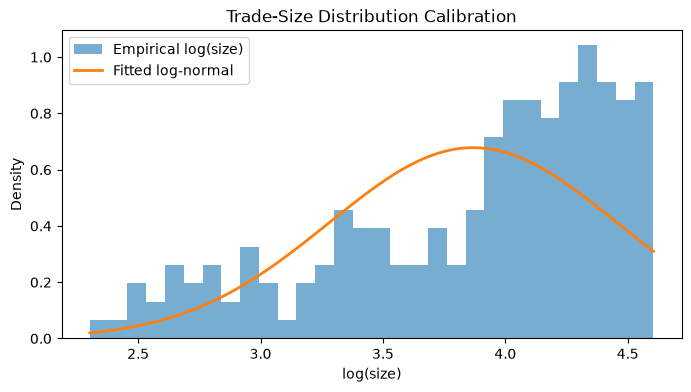

In [4]:
log_sizes = np.log(trades["size"])
x = np.linspace(log_sizes.min(), log_sizes.max(), 200)
pdf = (
    np.exp(-0.5 * ((x - params.size_lognorm_mu) / params.size_lognorm_sigma) ** 2)
    / (params.size_lognorm_sigma * np.sqrt(2 * np.pi))
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_sizes, bins=30, density=True, alpha=0.6, label="Empirical log(size)")
ax.plot(x, pdf, label="Fitted log-normal", lw=2)
ax.set_xlabel("log(size)")
ax.set_ylabel("Density")
ax.set_title("Trade-Size Distribution Calibration")
ax.legend();

## 4. Replay the quotes through the matching engine

In [5]:
# Merge quotes and trades into a single event stream.
quote_events = quotes.copy()
quote_events["event_type"] = "quote"
quote_events = quote_events.rename(columns={"bid_px_00": "bid_px", "ask_px_00": "ask_px"})

trade_events = trades.copy()
trade_events["event_type"] = "trade"

events = pd.concat([quote_events, trade_events], ignore_index=True)
events = events.sort_values("timestamp").reset_index(drop=True)

engine = ReplayEngine(default_quote_size=500)
simulated = engine.replay(events)

real_spreads = quotes["ask_px_00"] - quotes["bid_px_00"]
sim_spreads = simulated["spread"]
overlap = validate_spread_distribution(real_spreads, sim_spreads)
print(f"Spread-distribution overlap: {overlap:.3f}")

Spread-distribution overlap: 1.000


## 5. Overlay real and simulated spread histograms

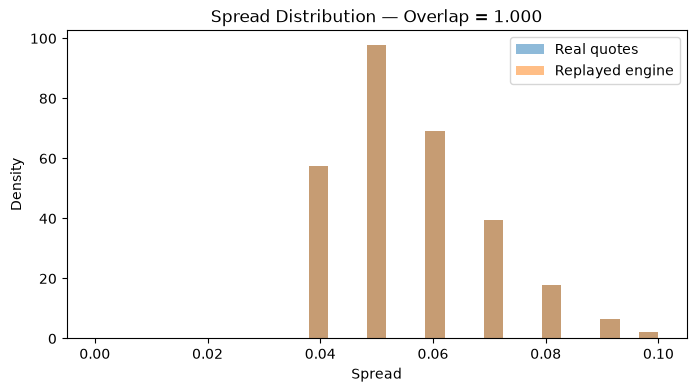

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.linspace(0, max(real_spreads.max(), sim_spreads.max()), 30)
ax.hist(real_spreads, bins=bins, density=True, alpha=0.5, label="Real quotes")
ax.hist(sim_spreads.dropna(), bins=bins, density=True, alpha=0.5, label="Replayed engine")
ax.set_xlabel("Spread")
ax.set_ylabel("Density")
ax.set_title(f"Spread Distribution — Overlap = {overlap:.3f}")
ax.legend();

## 6. Calibrated parameter table

These values can be passed directly to `NoiseTrader`, `MarketMaker`, `SkewedMarketMaker`, and `PropagatorImpact` to run a simulation that is statistically aligned with the input data.

In [7]:
table = pd.DataFrame([{
    "Parameter": "arrival_rate",
    "Value": params.arrival_rate,
    "Unit": "events/sec",
}, {
    "Parameter": "size_lognorm_mu",
    "Value": params.size_lognorm_mu,
    "Unit": "log(size)",
}, {
    "Parameter": "size_lognorm_sigma",
    "Value": params.size_lognorm_sigma,
    "Unit": "log(size)",
}, {
    "Parameter": "mean_spread",
    "Value": params.mean_spread,
    "Unit": "price units",
}, {
    "Parameter": "tick_size",
    "Value": params.tick_size,
    "Unit": "price units",
}, {
    "Parameter": "permanent_impact",
    "Value": params.permanent_impact,
    "Unit": "price / signed volume",
}, {
    "Parameter": "temporary_impact",
    "Value": params.temporary_impact,
    "Unit": "price / signed volume",
}, {
    "Parameter": "impact_decay",
    "Value": params.impact_decay,
    "Unit": "dimensionless",
}])
table

,Parameter,Value,Unit
0,arrival_rate,0.199799,events/sec
1,size_lognorm_mu,3.868560,log(size)
2,size_lognorm_sigma,0.588303,log(size)
3,mean_spread,0.056230,price units
4,tick_size,0.010000,price units
5,permanent_impact,0.001949,price / signed volume
6,temporary_impact,-0.001606,price / signed volume
7,impact_decay,0.200000,dimensionless
